# 0. Library

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from feature_engine.imputation import MeanMedianImputer
from feature_engine.selection import DropConstantFeatures, SmartCorrelatedSelection, DropDuplicateFeatures
from feature_engine.outliers import Winsorizer
from feature_engine.transformation import YeoJohnsonTransformer
from sklearn.preprocessing import StandardScaler
import os

import warnings
warnings.filterwarnings('ignore')

# Suppress TensorFlow logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# 1. Reading file with Importance of the Descriptors

In [17]:
df_imp = pd.read_csv('./5-Feature_Importance/V2-feature_importance_model_PermImp.csv')
df_imp.head(2)

,Feature,Importance
0,PubchemFP461,0.009318
1,PubchemFP755,0.006300


In [18]:
df_imp.shape

(1858, 2)

# 2. Selecting Only Features with positive contribution:

In [19]:
df_imp_pos = df_imp[df_imp['Importance']>0]
df_imp_pos.shape[0]

1030

In [20]:
df_imp_pos['Importance'].min()

1.0001948053228738e-06

In [21]:
df_imp_pos['Importance'].max()

0.0093179311212038

In [22]:
# Find all features with prefix 'ligand-'

ligand_features_3d = df_imp_pos[df_imp_pos['Feature'].str.startswith('3d-')]['Feature'].tolist()
print("3D Ligand features:")
print(len(ligand_features_3d))

ligand_features_FP = df_imp_pos[df_imp_pos['Feature'].str.startswith('PubchemFP')]['Feature'].tolist()
print("FP Ligand features:")
print(len(ligand_features_FP))

descr_1d_2d = 1030 - len(ligand_features_3d) - len(ligand_features_FP)
print("1D&2D")
print(descr_1d_2d)

3D Ligand features:
298
FP Ligand features:
134
1D&2D
598


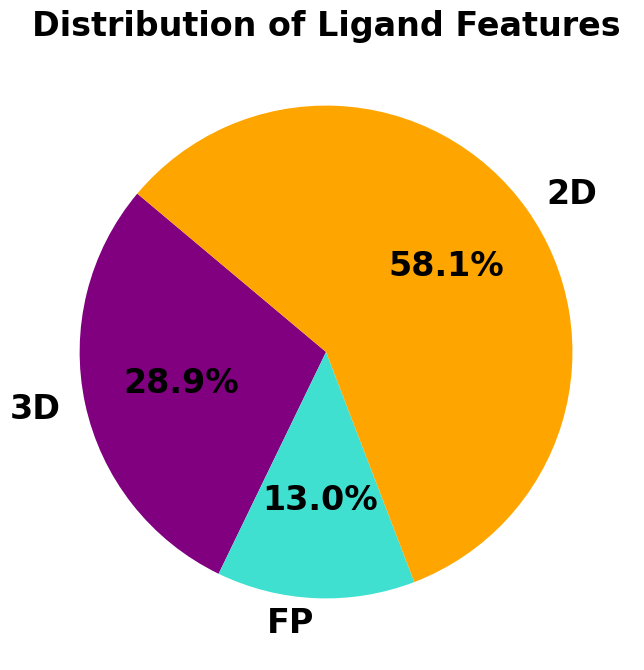

In [23]:
import matplotlib.pyplot as plt

# Sample counts (replace these with actual counts from your dataset)
ligand_features_3d_count = len(ligand_features_3d)
ligand_features_FP_count = len(ligand_features_FP)
descr_1d_2d_count = descr_1d_2d

# Data for the pie chart
labels = ['3D', 'FP', '2D']
sizes = [ligand_features_3d_count, ligand_features_FP_count, descr_1d_2d_count]
colors = ['purple','turquoise', 'orange']

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 24, 'weight': 'bold'})
plt.title('Distribution of Ligand Features', fontsize=24, weight='bold')
plt.show()



# 3. Grouping Features buy Importance and Analyze:

In [24]:
import pandas as pd

# Define the new bin edges based on the new interval
bins = [1e-06, 1e-05, 1e-04, 1e-03, 1e-02]

# Reverse the order of the labels to match the bins
labels = [f"Group_{i+1}" for i in range(len(bins) - 1)][::-1]

# Create the 'Group' column using pd.cut with the new bins and labels
df_imp_pos['Group'] = pd.cut(df_imp_pos['Importance'], bins=bins, labels=labels, right=False)

# Display the DataFrame with the new 'Group' column
df_imp_pos.head()

,Feature,Importance,Group
0,PubchemFP461,0.009318,Group_1
1,PubchemFP755,0.006300,Group_1
2,maxsBr,0.004837,Group_1
3,nFG12HeteroRing,0.003928,Group_1
4,nFG12Ring,0.003861,Group_1


In [25]:
df_imp_pos.shape[0]

1030

In [26]:
# Group by the 'Group' column and count the number of rows in each group
group_counts = df_imp_pos.groupby('Group').size()

In [27]:
group_counts

Group
Group_4     10
Group_3    111
Group_2    785
Group_1    124
dtype: int64

In [28]:
# Calculate number of Features without '3d-' or 'PubchemFP' prefixes (considered as '2D') for each group
grouped_counts = df_imp_pos.groupby('Group')['Feature'].apply(lambda x: pd.Series({
    'total': len(x),
    '2D': (~x.str.startswith(('3d-', 'ligand-PubchemFP'))).sum(),  # Features without '3d-' or 'PubchemFP' prefixes
    '3D': x.str.startswith('3d-').sum(),
    'PubchemFP': x.str.startswith('PubchemFP').sum()})).unstack()

# Calculate percentage of 2D, 3d-ligands, and ligand-PubchemFP in each group
grouped_counts['percentage_2D'] = ((grouped_counts['2D'] / grouped_counts['total']) * 100).round(1)
grouped_counts['percentage_3D'] = ((grouped_counts['3D'] / grouped_counts['total']) * 100).round(1)
grouped_counts['percentage_PubchemFP'] = ((grouped_counts['PubchemFP'] / grouped_counts['total']) * 100).round(1)

# Add a column of ranges for each group
ranges = {
    'Group_1': '1e-03 to 1e-02',
    'Group_2': '1e-04 to 1e-03',
    'Group_3': '1e-05 to 1e-04',
    'Group_4': '1e-06 to 1e-05',
    'Group_5': '5.5e-08 to 1.2e-06',
    #'Group_6': '5.5e-08 to 1.2e-06'  # Added to ensure all groups have ranges
}
grouped_counts['Importance Range'] = grouped_counts.index.map(ranges)

# Reorder columns to make 'Importance Range' the first column
grouped_counts = grouped_counts[['Importance Range', 'total', '2D', '3D', 'PubchemFP', 'percentage_2D', 'percentage_3D', 'percentage_PubchemFP']]

# Display the grouped counts
grouped_counts

,Importance Range,total,2D,3D,PubchemFP,percentage_2D,percentage_3D,percentage_PubchemFP
Group,,,,,,,,
Group_4,1e-06 to 1e-05,10,8,2,3,80.0,20.0,30.0
Group_3,1e-05 to 1e-04,111,78,33,15,70.3,29.7,13.5
Group_2,1e-04 to 1e-03,785,554,231,90,70.6,29.4,11.5
Group_1,1e-03 to 1e-02,124,92,32,26,74.2,25.8,21.0


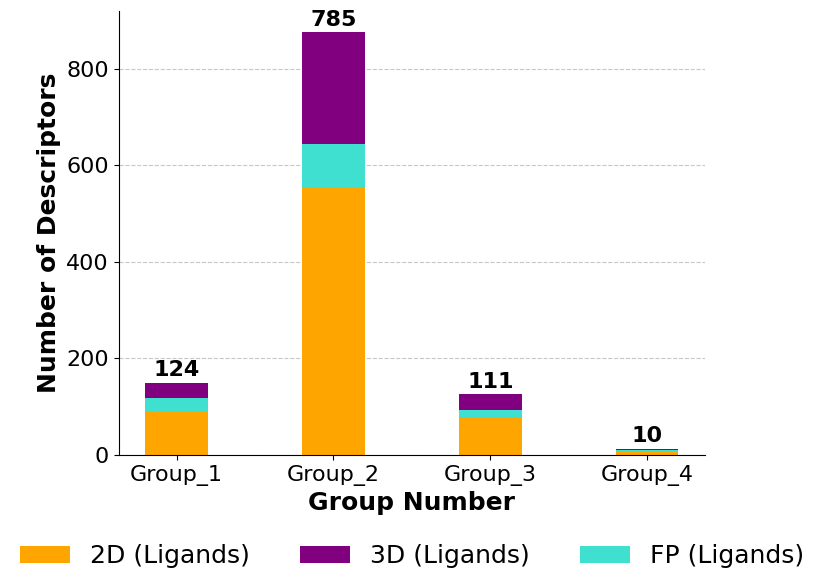

In [29]:
import matplotlib.pyplot as plt

# Ensure the correct order of the groups
grouped_counts = grouped_counts.reindex(['Group_1', 'Group_2', 'Group_3', 'Group_4'])

# Plot the bar chart
fig, ax = plt.subplots(figsize=(8, 6))

# Bar chart for the total number of descriptors
bar_width = 0.4
bar_2d_ligands = ax.bar(grouped_counts.index, grouped_counts['2D'], bar_width, label='2D (Ligands)', color='orange')
bar_3d_ligands = ax.bar(grouped_counts.index, grouped_counts['3D'], bar_width, bottom=grouped_counts['2D'] + grouped_counts['PubchemFP'], label='3D (Ligands)', color='purple')
bar_pubchemFP = ax.bar(grouped_counts.index, grouped_counts['PubchemFP'], bar_width, bottom=grouped_counts['2D'], label='FP (Ligands)', color='turquoise')

# Adding total number of features on top of each bar
for i in range(len(grouped_counts)):
    total_height = grouped_counts['2D'].iloc[i] + grouped_counts['PubchemFP'].iloc[i] + grouped_counts['3D'].iloc[i]
    ax.text(i, total_height + 5, f'{int(grouped_counts["total"].iloc[i])}', ha='center', va='bottom', fontweight='bold', fontsize=16, color='black')

# Labels and title
ax.set_xlabel('Group Number', fontsize=18, fontweight='bold')
ax.set_ylabel('Number of Descriptors', fontsize=18, fontweight='bold')

# Adjust the legend to be outside the plot
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=18, frameon=False)

# Improve layout
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()

# Save the figure
plt.savefig('grouped_bar_chart.png', dpi=600, bbox_inches='tight')

plt.show()


# 4. Descriptors by types (PADEL excel file)

PubChem FP: https://ftp.ncbi.nlm.nih.gov/pubchem/specifications/pubchem_fingerprints.txt

In [31]:
# Load the Excel file
padel = pd.read_csv('/expanse/lustre/projects/uci148/nvs/Backup/Paper2/Descriptors_2d_3d_fp_PADEL.csv', encoding='ISO-8859-1')

# Display the first two rows of the dataframe
padel.head(10)

,Descriptor Type,Descriptor,Description,Class
0,AcidicGroupCountDescriptor,nAcid,Number of acidic groups. The list of acidic gr...,2D
1,ALOGPDescriptor,ALogP,Ghose-Crippen LogKow,2D
2,ALOGPDescriptor,ALogP2,Square of ALogP,2D
3,ALOGPDescriptor,AMR,Molar refractivity,2D
4,APolDescriptor,apol,Sum of the atomic polarizabilities (including ...,2D
5,AromaticAtomsCountDescriptor,naAromAtom,Number of aromatic atoms,2D
6,AromaticBondsCountDescriptor,nAromBond,Number of aromatic bonds,2D
7,AtomCountDescriptor,nAtom,Number of atoms,2D
8,AtomCountDescriptor,nHeavyAtom,Number of heavy atoms (i.e. not hydrogen),2D
9,AtomCountDescriptor,nH,Number of hydrogen atoms,2D


In [32]:
df_imp_analys = df_imp.copy()

In [33]:
# Remove the prefix '3d-' from all values in the 'Feature' column
df_imp_analys['Feature'] = df_imp_analys['Feature'].str.replace('^3d-', '', regex=True)

# Display the updated dataframe
df_imp_analys.head(5)

,Feature,Importance
0,PubchemFP461,0.009318
1,PubchemFP755,0.006300
2,maxsBr,0.004837
3,nFG12HeteroRing,0.003928
4,nFG12Ring,0.003861


In [34]:
df_imp_analys.shape

(1858, 2)

In [35]:
# Rename the 'Feature' column to 'Descriptor'
df_imp_analys.rename(columns={'Feature': 'Descriptor'}, inplace=True)

# Display the updated dataframe
df_imp_analys.head()

,Descriptor,Importance
0,PubchemFP461,0.009318
1,PubchemFP755,0.006300
2,maxsBr,0.004837
3,nFG12HeteroRing,0.003928
4,nFG12Ring,0.003861


In [36]:
# Merge df_imp_analys with padel on the 'Descriptor' column, keeping all rows from df_imp_analys
merged_df = df_imp_analys.merge(padel, on='Descriptor', how='left')

# Display the first few rows of the merged dataframe
merged_df.head()


,Descriptor,Importance,Descriptor Type,Description,Class
0,PubchemFP461,0.009318,SMARTS patterns,O-C-C=N,FP
1,PubchemFP755,0.006300,SMARTS patterns 2,Cc1c(C)cccc1,FP
2,maxsBr,0.004837,ElectrotopologicalStateAtomTypeDescriptor,Maximum atom-type E-State: -Br,2D
3,nFG12HeteroRing,0.003928,RingCountDescriptor,Number of >12-membered fused rings containing ...,2D
4,nFG12Ring,0.003861,RingCountDescriptor,Number of >12-membered fused rings,2D


In [37]:
merged_df.to_csv('V2-feature_important_padel_PermImort.csv', index=False)

In [38]:
merged_df.shape

(1858, 5)

In [39]:
# Filter positive only:
df_imp_pos = merged_df[merged_df['Importance']>0]
df_imp_pos.shape[0]

1030

# 5. 3D contribution: by frequency

In [77]:
df_3d_pos = df_imp_pos[df_imp_pos['Class']=='3D']
df_3d_pos.shape

(298, 5)

In [78]:
df_3d_pos['Descriptor Type'].value_counts()

Descriptor Type
RDFDescriptor                         160
PaDELWHIMDescriptor                    62
Autocorrelation3DDescriptor            45
CPSADescriptor                         20
GravitationalIndexDescriptor            7
MomentOfInertiaDescriptor               2
PaDELPetitjeanShapeIndexDescriptor      1
LengthOverBreadthDescriptor             1
Name: count, dtype: int64

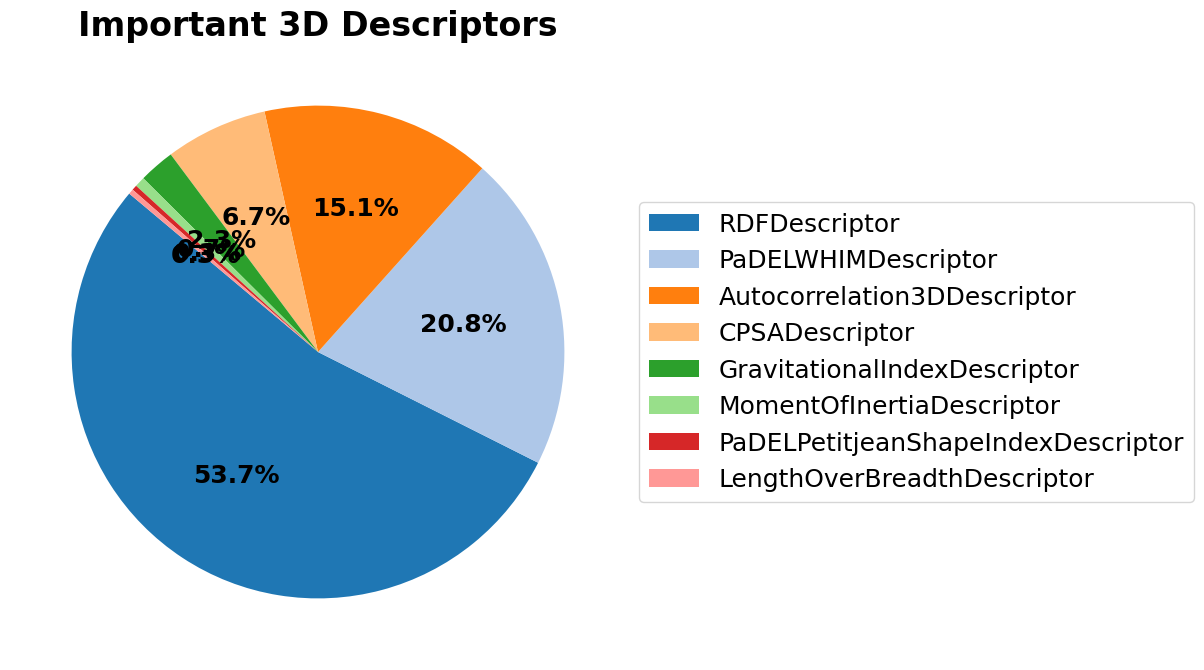

In [79]:
import matplotlib.pyplot as plt

descriptor_counts = df_3d_pos['Descriptor Type'].value_counts()

# Define a color palette
colors = plt.get_cmap('tab20').colors

# Plotting the pie chart without labels
plt.figure(figsize=(10, 8))
plt.pie(descriptor_counts, colors=colors, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 18, 'weight': 'bold'})

# Adding the title
plt.title('Important 3D Descriptors', fontsize=24, weight='bold')

# Adding the legend outside of the plot
plt.legend(descriptor_counts.index, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=18)

# Show the plot
plt.show()



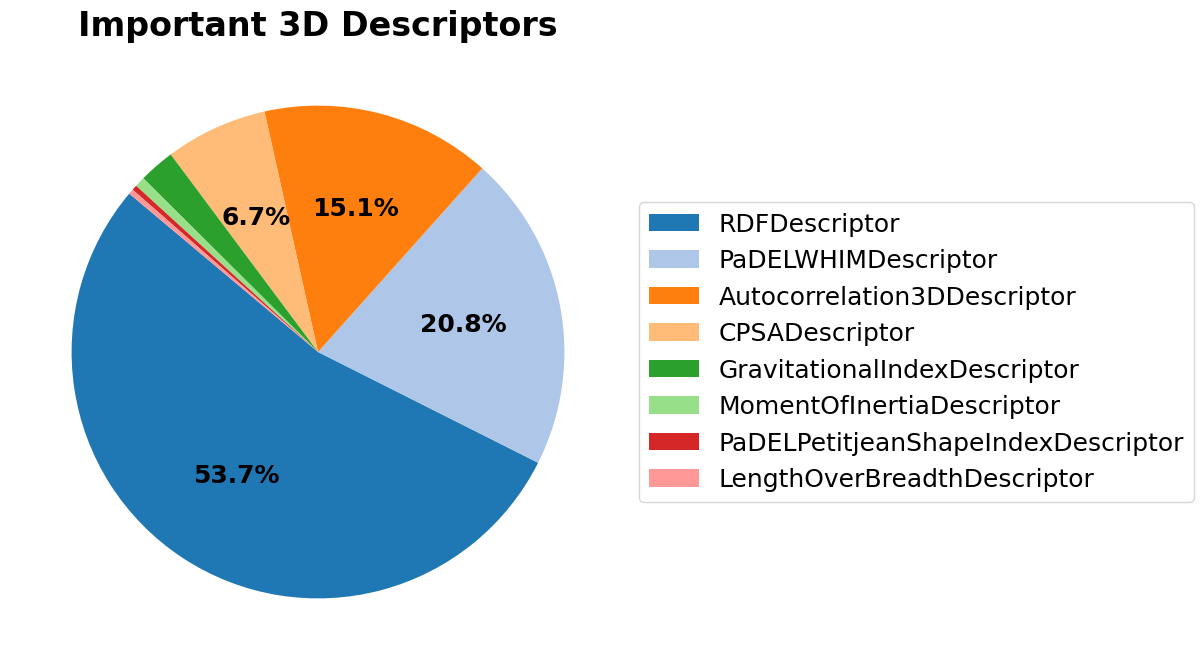

In [80]:
import matplotlib.pyplot as plt

descriptor_counts = df_3d_pos['Descriptor Type'].value_counts()

# Define a color palette
colors = plt.get_cmap('tab20').colors

# Custom autopct function to hide percentages below 3%
def autopct_func(pct):
    return ('%1.1f%%' % pct) if pct >= 3 else ''

# Plotting the pie chart without labels
plt.figure(figsize=(10, 8))
plt.pie(descriptor_counts, colors=colors, autopct=autopct_func, startangle=140, textprops={'fontsize': 18, 'weight': 'bold'})

# Adding the title
plt.title('Important 3D Descriptors', fontsize=24, weight='bold')

# Adding the legend outside of the plot
plt.legend(descriptor_counts.index, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=18)

# Show the plot
plt.show()




# 6. 3D by contribution: by Importance contribution

In [82]:
import pandas as pd

# Total importance value from merged_df
total_importance_sum = df_3d_pos['Importance'].sum()

# Group by 'Descriptor Type' and sum the 'Importance' for each group
grouped_importance = df_3d_pos.groupby('Descriptor Type')['Importance'].sum().reset_index()

# Calculate the percentage of the total importance
grouped_importance['Percentage'] = (grouped_importance['Importance'] / total_importance_sum) * 100

# Sort results_2d_df_grouped by 'Percentage'
grouped_importance = grouped_importance.sort_values(by='Percentage', ascending=False)

# Display the result
grouped_importance


,Descriptor Type,Importance,Percentage
7,RDFDescriptor,0.091036,59.300175
6,PaDELWHIMDescriptor,0.030791,20.057444
0,Autocorrelation3DDescriptor,0.017984,11.714762
1,CPSADescriptor,0.008616,5.612664
2,GravitationalIndexDescriptor,0.003029,1.973265
4,MomentOfInertiaDescriptor,0.001099,0.715693
5,PaDELPetitjeanShapeIndexDescriptor,0.000508,0.330973
3,LengthOverBreadthDescriptor,0.000453,0.295024


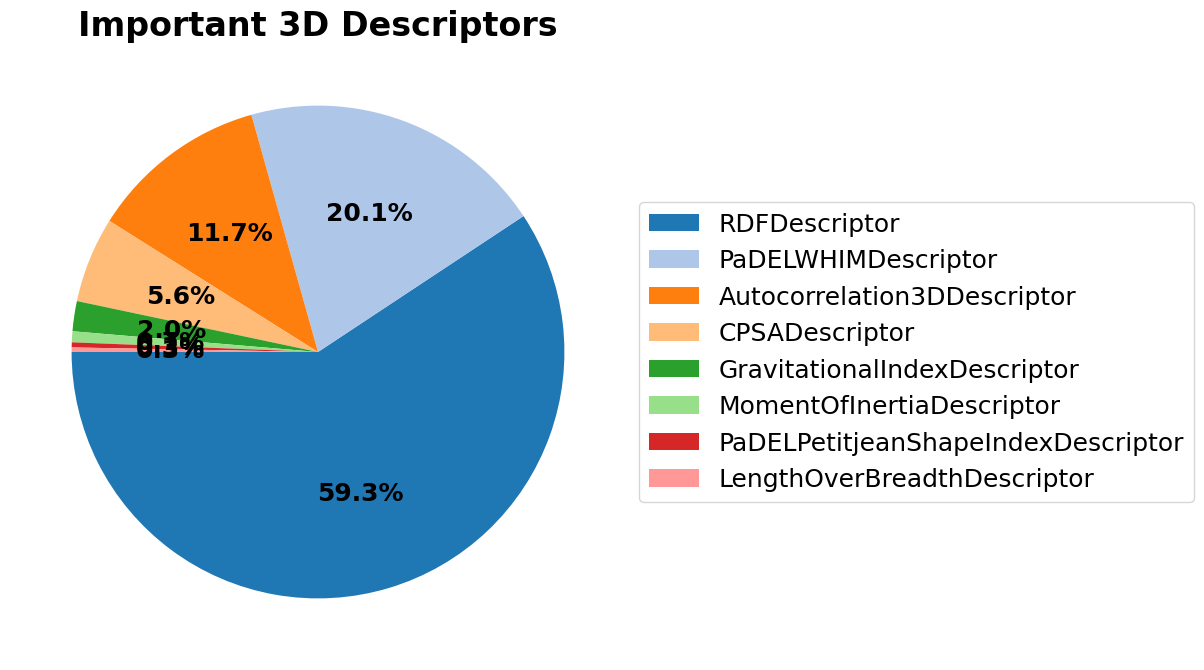

In [83]:
import matplotlib.pyplot as plt

descriptor_counts = grouped_importance['Percentage']
labels = grouped_importance['Descriptor Type']

# Define a color palette
colors = plt.get_cmap('tab20').colors

# Custom autopct function to hide percentages below 3%
def autopct_func(pct):
    return ('%1.1f%%' % pct) if pct >= 0.1 else ''

# Plotting the pie chart without labels
plt.figure(figsize=(10, 8))
plt.pie(descriptor_counts, colors=colors, autopct=autopct_func, startangle=180, textprops={'fontsize': 18, 'weight': 'bold'})

# Adding the title
plt.title('Important 3D Descriptors', fontsize=24, weight='bold')

# Adding the legend outside of the plot
plt.legend(labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=18)

# Show the plot
plt.show()



# 7. 2D By Importance

In [47]:
df_2d_pos = df_imp_pos[df_imp_pos['Class']=='2D']
df_2d_pos.shape

(597, 5)

In [50]:
import pandas as pd

# Total importance value from merged_df
total_importance_sum = df_2d_pos['Importance'].sum()

# Group by 'Descriptor Type' and sum the 'Importance' for each group
grouped_importance = df_2d_pos.groupby('Descriptor Type')['Importance'].sum().reset_index()

# Calculate the percentage of the total importance
grouped_importance['Percentage'] = (grouped_importance['Importance'] / total_importance_sum) * 100

# Display the result
grouped_importance

,Descriptor Type,Importance,Percentage
0,ALOGPDescriptor,0.001161,0.380306
1,APolDescriptor,0.000289,0.094667
2,AtomCountDescriptor,0.004584,1.501225
3,AutocorrelationDescriptor,0.101624,33.278336
4,BCUTDescriptor,0.002192,0.717694
5,BPolDescriptor,0.000696,0.228078
6,BaryszMatrixDescriptor,0.015504,5.077104
7,BasicGroupCountDescriptor,0.000164,0.053793
8,BurdenModifiedEigenvaluesDescriptor,0.031048,10.167183
9,ChiClusterDescriptor,0.002548,0.834485


In [51]:
import pandas as pd

results_2d_df = grouped_importance.copy()

# Add a new column 'labels' based on the condition
results_2d_df['labels'] = grouped_importance.apply(lambda row: row['Descriptor Type'] if row['Percentage'] > 2 else 'Rare', axis=1)

# Display the DataFrame
results_2d_df


,Descriptor Type,Importance,Percentage,labels
0,ALOGPDescriptor,0.001161,0.380306,Rare
1,APolDescriptor,0.000289,0.094667,Rare
2,AtomCountDescriptor,0.004584,1.501225,Rare
3,AutocorrelationDescriptor,0.101624,33.278336,AutocorrelationDescriptor
4,BCUTDescriptor,0.002192,0.717694,Rare
5,BPolDescriptor,0.000696,0.228078,Rare
6,BaryszMatrixDescriptor,0.015504,5.077104,BaryszMatrixDescriptor
7,BasicGroupCountDescriptor,0.000164,0.053793,Rare
8,BurdenModifiedEigenvaluesDescriptor,0.031048,10.167183,BurdenModifiedEigenvaluesDescriptor
9,ChiClusterDescriptor,0.002548,0.834485,Rare


In [52]:
import pandas as pd

results_2d_df = grouped_importance.copy()

# Add a new column 'labels' based on the condition
results_2d_df['labels'] = grouped_importance.apply(lambda row: row['Descriptor Type'] if row['Percentage'] > 2 else 'Rare', axis=1)

# Group by 'labels' and sum the 'Count' where labels are the same
results_2d_df_grouped = results_2d_df.groupby('labels', as_index=False).agg({'Percentage': 'sum'})

# Sort results_2d_df_grouped by 'Percentage'
results_2d_df_grouped = results_2d_df_grouped.sort_values(by='Percentage', ascending=False)

# Display the DataFrame
results_2d_df_grouped

,labels,Percentage
0,AutocorrelationDescriptor,33.278336
4,ElectrotopologicalStateAtomTypeDescriptor,19.957731
7,Rare,15.022547
2,BurdenModifiedEigenvaluesDescriptor,10.167183
6,InformationContentDescriptor,5.241043
1,BaryszMatrixDescriptor,5.077104
8,RingCountDescriptor,3.503806
5,ExtendedTopochemicalAtomDescriptor,2.979899
9,TopologicalChargeDescriptor,2.760388
3,DetourMatrixDescriptor,2.011962


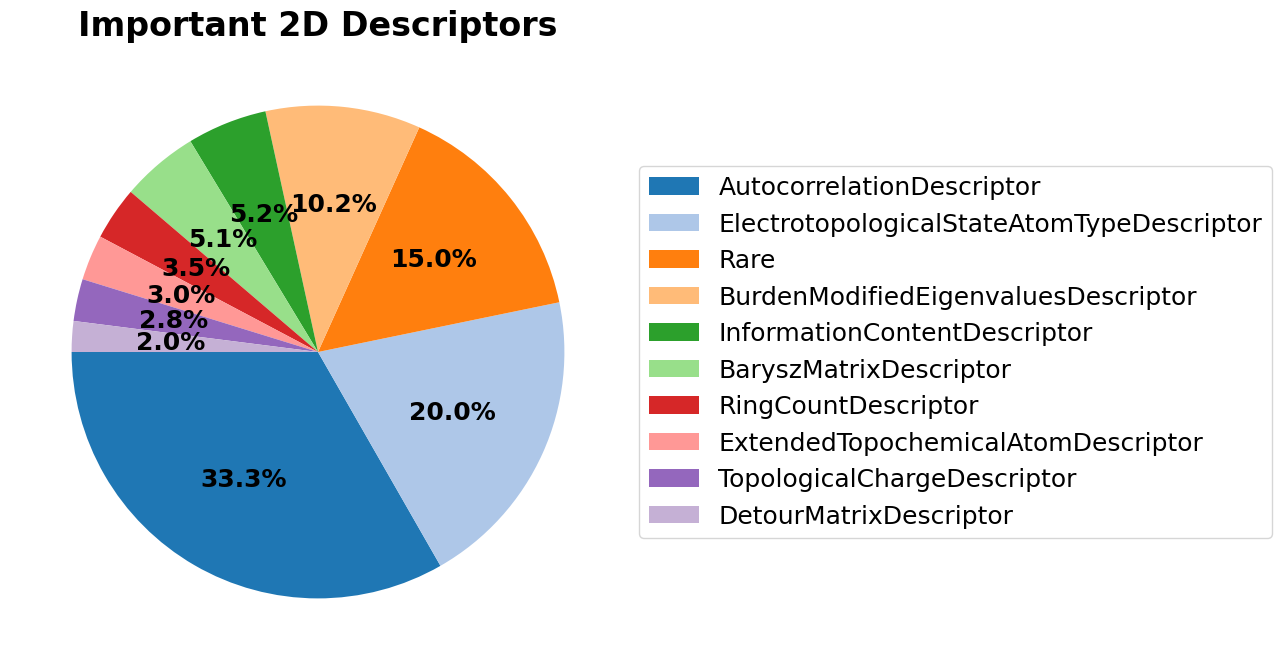

In [53]:
import matplotlib.pyplot as plt

labels = results_2d_df_grouped['labels']

# Define a color palette
colors = plt.get_cmap('tab20').colors

# Plotting the pie chart without segment labels but using 'labels' for the legend
plt.figure(figsize=(10, 8))
plt.pie(descriptor_counts, colors=colors, autopct='%1.1f%%', startangle=180, textprops={'fontsize': 18, 'weight': 'bold'})

# Adding the title
plt.title('Important 2D Descriptors', fontsize=24, weight='bold')

# Adding the legend outside of the plot using 'labels'
plt.legend(labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=18, ncol=1)

# Show the plot
plt.show()



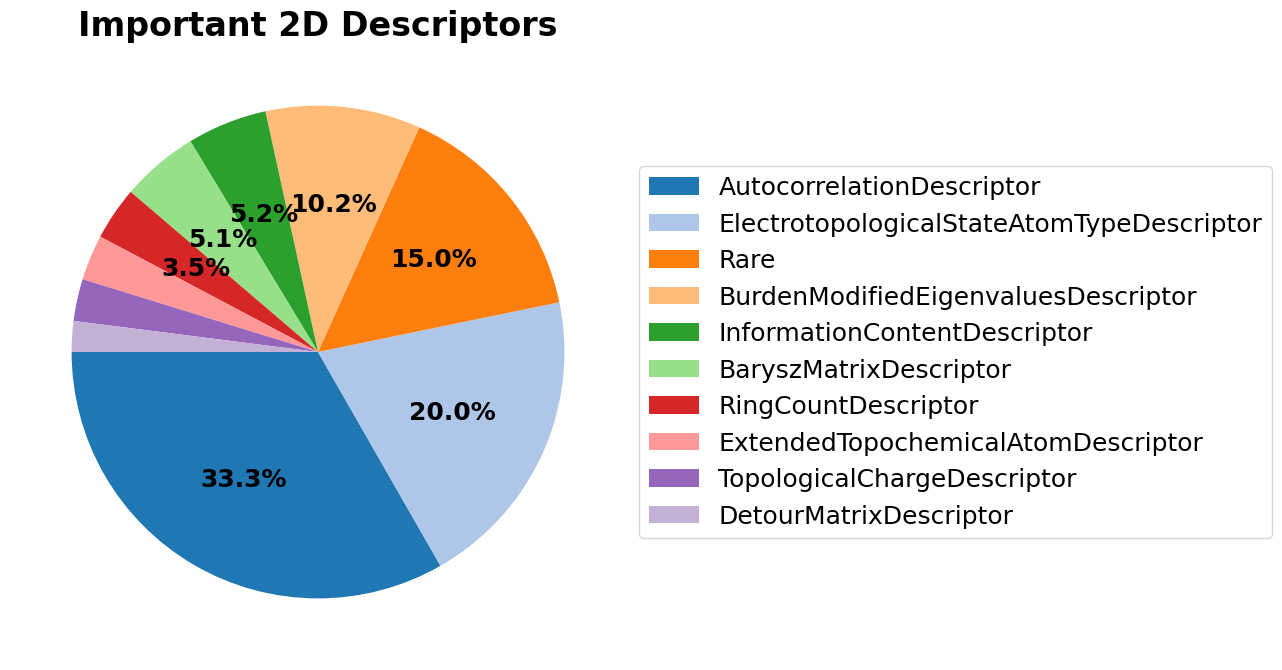

In [84]:
import matplotlib.pyplot as plt

descriptor_counts = results_2d_df_grouped['Percentage']
labels = results_2d_df_grouped['labels']

# Define a color palette
colors = plt.get_cmap('tab20').colors

# Custom autopct function to hide percentages below 3.5%
def autopct_func(pct):
    return ('%1.1f%%' % pct) if pct >= 3.5 else ''

# Plotting the pie chart without segment labels but using 'labels' for the legend
plt.figure(figsize=(10, 8))
plt.pie(descriptor_counts, colors=colors, autopct=autopct_func, startangle=180, textprops={'fontsize': 18, 'weight': 'bold'})

# Adding the title
plt.title('Important 2D Descriptors', fontsize=24, weight='bold')

# Adding the legend outside of the plot using 'labels'
plt.legend(labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=18, ncol=1)

# Show the plot
plt.show()



# 8. FP by Importance

In [63]:
df_fp_pos = df_imp_pos[df_imp_pos['Class']=='FP']
df_fp_pos.shape

(134, 5)

In [64]:
df_fp_pos['Descriptor Type'].value_counts()

Descriptor Type
SMARTS patterns                                                                           60
SMARTS patterns 2                                                                         23
Atom Nearest Neighbors ("~" bond, ":"bond aromaticity)                                    17
Chemical Rings                                                                            13
Atom Neighborhoods ("-", "=", and "#" matches a single, double, and triple bond order)    11
Element Counts                                                                             8
Atom Pairs                                                                                 2
Name: count, dtype: int64

In [73]:
import pandas as pd

# Total importance value from merged_df
total_importance_sum = df_fp_pos['Importance'].sum()

# Group by 'Descriptor Type' and sum the 'Importance' for each group
grouped_importance = df_fp_pos.groupby('Descriptor Type')['Importance'].sum().reset_index()

# Calculate the percentage of the total importance
grouped_importance['Percentage'] = (grouped_importance['Importance'] / total_importance_sum) * 100

# Sort results_2d_df_grouped by 'Percentage'
grouped_importance = grouped_importance.sort_values(by='Percentage', ascending=False)

# Display the result
grouped_importance

,Descriptor Type,Importance,Percentage
5,SMARTS patterns,0.045277,45.969141
6,SMARTS patterns 2,0.026133,26.532934
0,"Atom Nearest Neighbors (""~"" bond, "":""bond arom...",0.008639,8.771146
3,Chemical Rings,0.007906,8.026506
1,"Atom Neighborhoods (""-"", ""="", and ""#"" matches ...",0.005976,6.066978
4,Element Counts,0.002977,3.022347
2,Atom Pairs,0.001587,1.610949


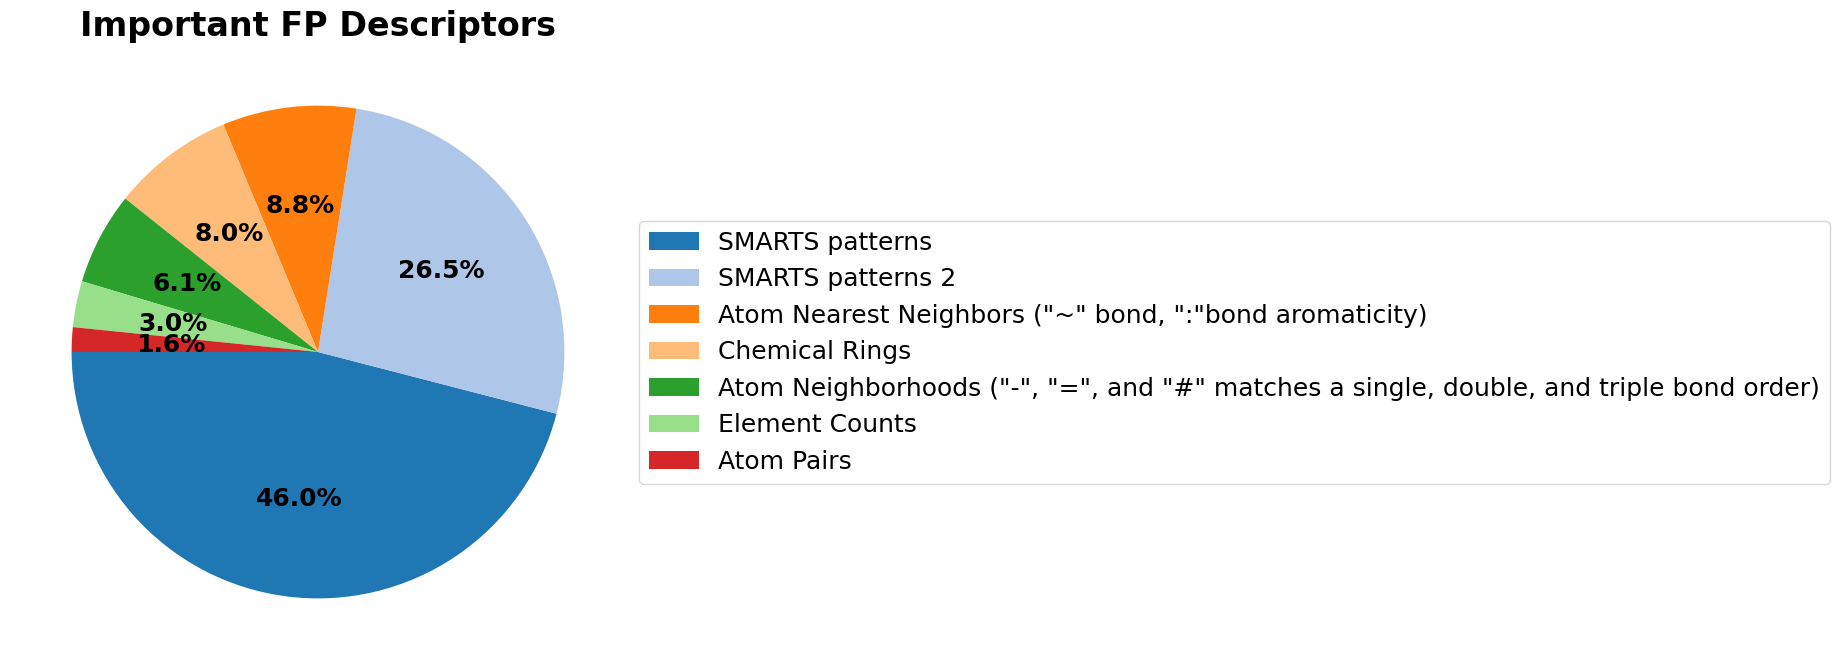

In [75]:
import matplotlib.pyplot as plt

# Assuming df_3d_pos is your DataFrame and 'Descriptor Type' is the column of interest
descriptor_counts = grouped_importance['Percentage']
labels = grouped_importance['Descriptor Type']

# Define a color palette
colors = plt.get_cmap('tab20').colors

# Custom autopct function to hide percentages below 3%
def autopct_func(pct):
    return ('%1.1f%%' % pct) if pct >= 1.1 else ''

# Plotting the pie chart without labels
plt.figure(figsize=(10, 8))
plt.pie(descriptor_counts, colors=colors, autopct=autopct_func, startangle=180, textprops={'fontsize': 18, 'weight': 'bold'})

# Adding the title
plt.title('Important FP Descriptors', fontsize=24, weight='bold')

# Adding the legend outside of the plot
plt.legend(labels, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=18)

# Show the plot
plt.show()